<a href="https://colab.research.google.com/github/M90X-2/IT480-FA26/blob/main/Assignment1_hyperparameter_tuning_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [17]:
def plot_history(history, title, show_accuracy=False):
    if show_accuracy:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        axes[0].plot(history.history["loss"], label="Training Loss")
        axes[0].plot(history.history["val_loss"], label="Validation Loss")
        axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
        axes[0].set_title(title + " -- Loss")

        axes[1].plot(history.history["accuracy"], label="Training Accuracy")
        axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
        axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()
        axes[1].set_title(title + " -- Accuracy")
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(6, 4))
        plt.plot(history.history["loss"], label="Training Loss")
        plt.plot(history.history["val_loss"], label="Validation Loss")
        plt.xlabel("Epoch"); plt.ylabel("Loss (MSE, scaled)"); plt.title(title); plt.legend()
        plt.show()

---
# Part 3 — Multiclass Classification (Wine Quality)

Raw wine quality scores are heavily imbalanced at the extremes, so we bucket them into
3 broader bands to make this a genuine, learnable multiclass problem.

In [18]:
wine = fetch_openml(name="wine-quality-red", version=1, as_frame=True, parser="auto")
df3 = wine.frame

print(df3.shape)
print(df3["class"].astype(int).value_counts().sort_index())

(1599, 12)
class
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [19]:
# Bucket raw quality scores into 3 bands: low / medium / high
def bucket_quality(q):
    q = int(q)
    if q <= 5:
        return 0  # low
    elif q == 6:
        return 1  # medium
    else:
        return 2  # high

df3["quality_band"] = df3["class"].apply(bucket_quality)
print(df3["quality_band"].value_counts().sort_index())

# Q: How many classes do we have now? Are they reasonably balanced?
# Your answer: 3 classes, no the third class is much smaller compared to the others


quality_band
0    744
1    638
2    217
Name: count, dtype: int64


**Encode your labels.** We'll use integer labels (0, 1, 2) with `sparse_categorical_crossentropy` — this avoids a separate one-hot encoding step for the labels. (An equally valid alternative: one-hot encode the labels with `to_categorical` and use plain `categorical_crossentropy` instead — same result, different bookkeeping.)

In [20]:
X3 = df3.drop(columns=["class", "quality_band"]).values.astype(float)
y3 = df3["quality_band"].values.astype(int)

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42, stratify=y3
)

x3_scaler = StandardScaler()
X3_train_scaled = x3_scaler.fit_transform(X3_train)
X3_test_scaled = x3_scaler.transform(X3_test)

**Build your MLP.** This time, fill in the number of output neurons too — it's no longer fixed at 1.

In [21]:
n_classes = len(np.unique(y3))

# Create the classification model
model_multi = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation="relu", input_shape=(X3_train_scaled.shape[1],)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(n_classes, activation="softmax")
])

model_multi.compile(optimizer= "adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Q: How many output neurons did you use, and why is that number tied to n_classes?
# Your answers: n_classes (3) because there are 3 output categories.

# Q: What activation function turns raw outputs into class probabilities that sum to 1?
# Your answers: Softmax activation.

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


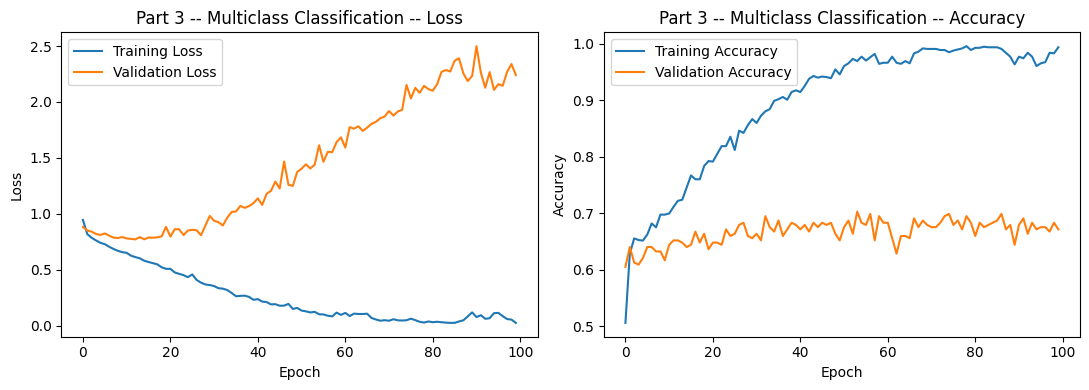

In [22]:
history_multi = model_multi.fit(
    X3_train_scaled, y3_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

plot_history(history_multi, "Part 3 -- Multiclass Classification", show_accuracy=True)

**Diagnose:** good fit, overfitting, or underfitting? Write 1–2 sentences.

*Your answer:*


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Part 3 -- Test Accuracy: 0.691


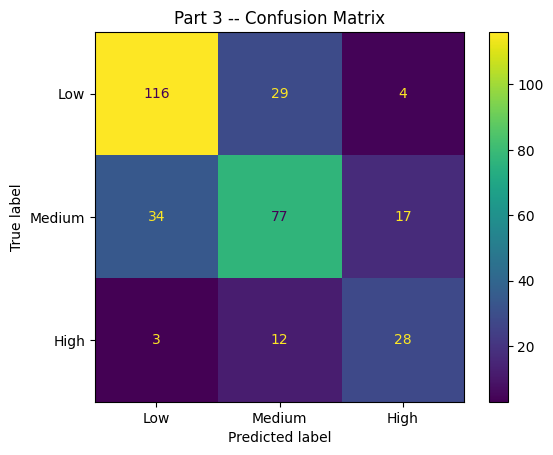

In [23]:
multi_probs = model_multi.predict(X3_test_scaled)
multi_preds = np.argmax(multi_probs, axis=1)

acc_multi = accuracy_score(y3_test, multi_preds)
print(f"Part 3 -- Test Accuracy: {acc_multi:.3f}")

cm3 = confusion_matrix(y3_test, multi_preds)
ConfusionMatrixDisplay(cm3, display_labels=["Low", "Medium", "High"]).plot()
plt.title("Part 3 -- Confusion Matrix")
plt.show()

# Q: Which classes does your model confuse most often? Does that make sense
# given how the quality bands were constructed?
# Your answer:


#Part A: Restate Your Baseline (10 points)

**Restate its original test accuracy, and describe what its training versus validation loss curve looked
like. Did it show overfitting? Point to specific evidence from the curve (where the gap appeared, and what happened to validation loss as training continued)**
The baseline test accuracy was 0.684 or 68.4%. The model shows clear overfitting, evidenced by a widening gap appearing between the curves early in the training process. The training loss steadily decreased toward zero, while the validation loss starts out going down then around epoch 17 gradually increases until the end of training.

In [31]:
!pip install keras-tuner --quiet
import keras_tuner as kt
n_features = X3_train_scaled.shape[1]
def build_model(hp):
  model = tf.keras.Sequential([
    tf.keras.layers.Dense(
      hp.Int("hidden1", min_value=16, max_value=128, step=16),
      activation="relu", input_shape=(n_features,)
    ),
    tf.keras.layers.Dense(
      hp.Int("hidden2", min_value=8, max_value=64, step=8),
      activation="relu", input_shape=(n_features,)
    ),
    tf.keras.layers.Dense(n_classes, activation="softmax")
  ])
  model.compile(
    optimizer=tf.keras.optimizers.Adam(
      hp.Choice("learning_rate", [0.001, 0.01, 0.1])
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
  )
  return model
tuner = kt.RandomSearch(
  build_model,
  objective="val_loss",
  max_trials=15,
  overwrite=True
)
tuner.search(
  X3_train_scaled, y3_train,
  validation_split=0.2, epochs=50, verbose=0
  )
best_model = tuner.get_best_models(num_models=1)[0]
best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)
best_trial = tuner.oracle.get_best_trials(num_trials=1)[0]
print(f"Best validation score (val_loss): {best_trial.score:.4f}")

{'hidden1': 96, 'hidden2': 24, 'learning_rate': 0.001}
Best validation score (val_loss): 0.7503


In [32]:
print("Training final model with best hyperparameters...")
final_model = tuner.hypermodel.build(best_hp)

history_final = final_model.fit(
    X3_train_scaled, y3_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

final_loss, final_acc = final_model.evaluate(X3_test_scaled, y3_test, verbose=0)
print(f"Final Test Accuracy: {final_acc:.3f}")

Training final model with best hyperparameters...
Final Test Accuracy: 0.675


#Part B: Hyperparameter Tuning (40 points)
1. Using Keras Tuner, define a search space of at least 3 hyperparameters.
2. Run the search using training data only. Do not touch your test set during this step.
3. Report the best configuration found and its validation score.
4. Train a final model using that configuration, and evaluate it once on your test set.
5. Compare this result to your original Lab 1 baseline. Did it improve, and by how much?

Answer: 3. There were 15 trials done to test out the best configurations. Out of the 15 trials the reported best configuration found is 96 for hidden layer 1, 24 for hidden layer 2, and 0.001 for the learning rate, as well as a validation score of 0.7503. 5. The model came out with a lower final test accuracy at 0.675 or 67.5% which is nearly a full percent lower than the original.


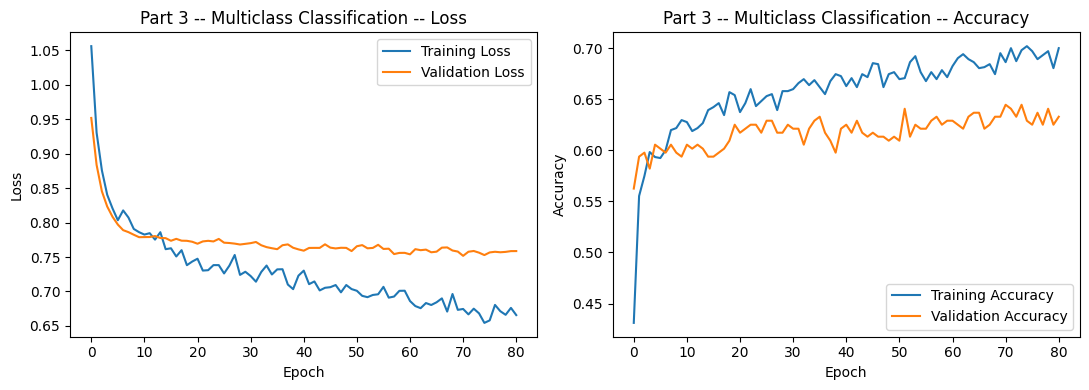

In [36]:
final_model = tf.keras.Sequential([
  tf.keras.layers.Dense(
    96, activation="relu", input_shape=(n_features,)
  ),
  tf.keras.layers.Dropout(0.3),
  tf.keras.layers.Dense(24, activation="relu"),
  tf.keras.layers.Dropout(0.3),
  tf.keras.layers.Dense(n_classes, activation="softmax")
])

early_stop = tf.keras.callbacks.EarlyStopping(
  monitor="val_loss",
  patience=10,
  restore_best_weights=True
)

final_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = final_model.fit(
  X3_train_scaled, y3_train,
  validation_split=0.2,
  epochs=200,
  callbacks=[early_stop],
  verbose=0
)

plot_history(history, "Part 3 -- Multiclass Classification", show_accuracy=True)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Part 3 -- Test Accuracy: 0.684


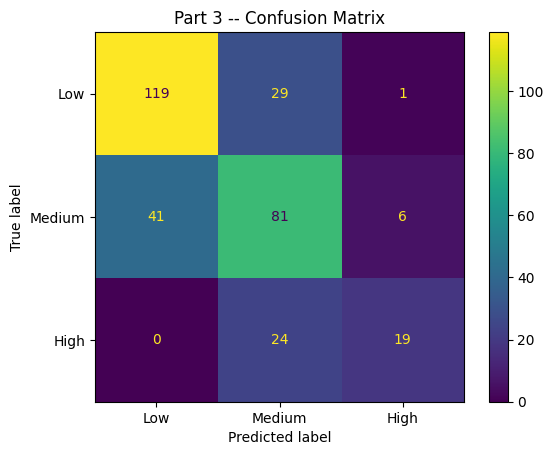

In [37]:
final_probs = final_model.predict(X3_test_scaled)
final_preds = np.argmax(final_probs, axis=1)

acc_final = accuracy_score(y3_test, final_preds)
print(f"Part 3 -- Test Accuracy: {acc_final:.3f}")

cm_f = confusion_matrix(y3_test, final_preds)
ConfusionMatrixDisplay(cm_f, display_labels=["Low", "Medium", "High"]).plot()
plt.title("Part 3 -- Confusion Matrix")
plt.show()

#Part C: Addressing Overfitting (30 points)
1. Apply Dropout, Early Stopping, or both to your tuned model from Part B.
2. Retrain, replot the training versus validation loss curve, and compare it directly to your original Lab
1 curve from Part A.
3. Did the gap between training and validation loss shrink? Did validation loss stop rising, or improve
further into training than before?
4. Report your final test accuracy and confusion matrix. Which classes are still being confused most
often, and has that changed from Lab 1?

Answer: 3. After retraining and replotting the training vs validation loss curve and comparing it to the original lab 1 curve I can see that the gap shrun dramatically and is now withing range of the training loss, although still overfitting. The validation loss instead of rising not seven out and stays around 0.77 whereas before it would conitnue to rise back up. 4. The final test accuracy ended up being 0.684 or 68.4% accuracy with the confusion matrix having high as it's class that is confused most often. This holds true for the original as well.

#Part D: Reflection (20 points)
Answer in 4 to 6 sentences total:
1. Why is it important that your test set was touched only once, at the very end?
2. What would have gone wrong if you had used your test set to pick the best hyperparameter
configuration instead of a validation split?
3. Did Dropout or Early Stopping meaningfully reduce the overfitting you saw in Lab 1? What
evidence from your new loss curve supports your answer?
4. If you had unlimited time and compute, what would you try next to improve this model further?

Answer: It is crucial to only touch the test set one at the end as it ensures that it remains an unseen benchmark for the model and provides an unbiased evaluation of how the model generalizes to new data. If the test set had been used to select the best hyperparameter, the model would have learned from the test data, which would result in data leakage and an inflated final accuracy score. Implementing the dropout and early stopping meaningfully reduced the overfitting seen in the original lab 1, which was supported by the new val loss curve where the validation loss flattened out around 0.77 instead of rising continuously. With unlimited time and computing power, the next step I would take is running a larger keras tuner search with expanded layer sizes, more trials, and increased parameters.